NAME : SHAQEEQ S
Roll No : 24BAD109

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
 Cu

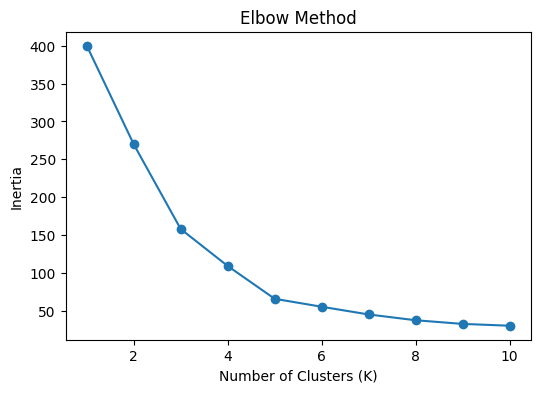


Clustered Data:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


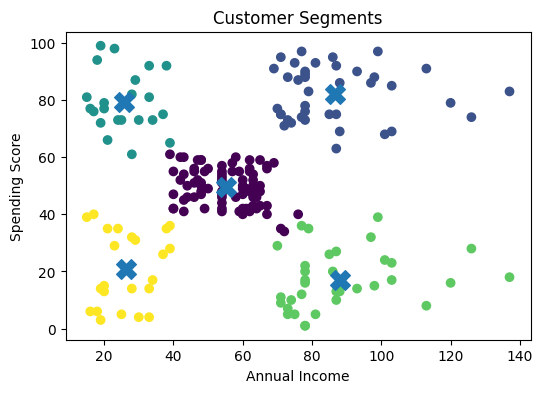


Cluster Summary:
          Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv("C:\\Users\\HP\\Downloads\\Mall_Customers.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())



# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Select relevant features
# You can include Age if required
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Optional (uncomment to include Age)
# X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

optimal_k = 5  # Choose based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nClustered Data:\n", df.head())


print("\nInertia:", kmeans.inertia_)

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

plt.figure(figsize=(6,4))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'])


centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("\nCluster Summary:\n", cluster_summary)

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# For comparison
from sklearn.cluster import KMeans
df = pd.read_csv("C:\\Users\\HP\\Downloads\\Mall_Customers.csv")

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()
df.isnull().sum()# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


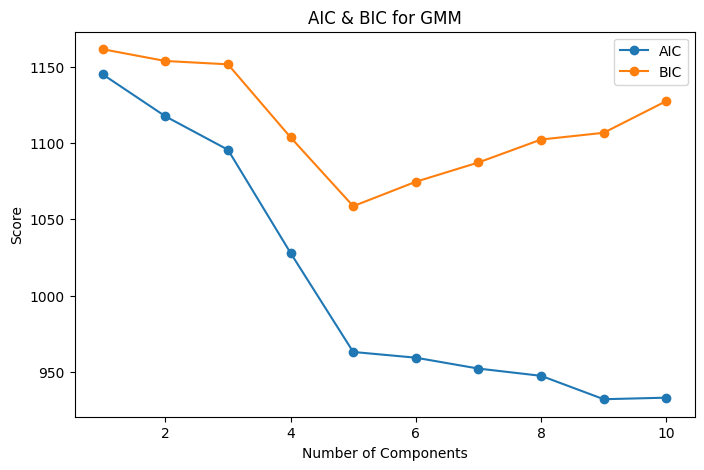

In [5]:
aic = []
bic = []

K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# Plot AIC & BIC
plt.figure(figsize=(8,5))
plt.plot(K_range, aic, label='AIC', marker='o')
plt.plot(K_range, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('AIC & BIC for GMM')
plt.legend()
plt.show()

In [6]:
# Choose optimal components (example: 5)
gmm = GaussianMixture(n_components=5, random_state=42)

# Fit model (EM algorithm)
gmm.fit(X_scaled)

,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [17]:
# Soft clustering (probabilities)
probs = gmm.predict_proba(X_scaled)

# Show first few probability distributions
pd.DataFrame(probs).head()

,0,1,2,3,4
0,1.576897e-05,1.880092e-08,9.520312e-04,5.200131e-08,0.999032
1,1.627762e-05,1.895968e-04,9.997902e-01,4.210134e-23,0.000004
2,2.213394e-19,9.526157e-19,1.225495e-12,1.862233e-04,0.999814
3,1.054448e-04,1.800877e-04,9.996937e-01,3.793901e-21,0.000021
4,6.473014e-05,3.842732e-08,1.556695e-03,4.757227e-08,0.998378


In [8]:
# Hard clustering
labels = gmm.predict(X_scaled)

df['GMM_Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [9]:
# Log Likelihood
log_likelihood = gmm.score(X_scaled)
print("Log-Likelihood:", log_likelihood)

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


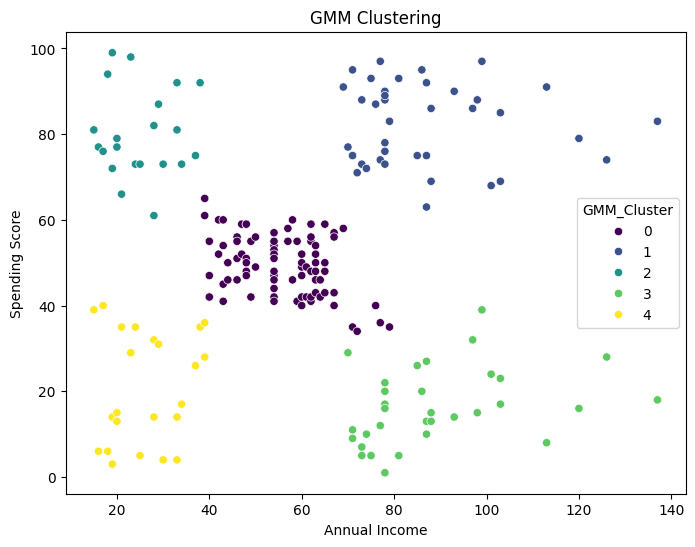

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)

plt.title('GMM Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

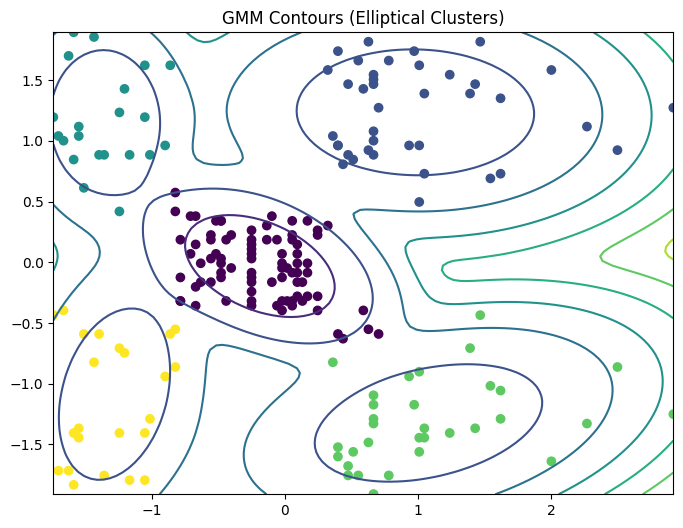

In [11]:
# Create grid for contour
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(8,6))
plt.contour(X_grid, Y_grid, Z)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.title('GMM Contours (Elliptical Clusters)')
plt.show()

<Figure size 1000x500 with 0 Axes>

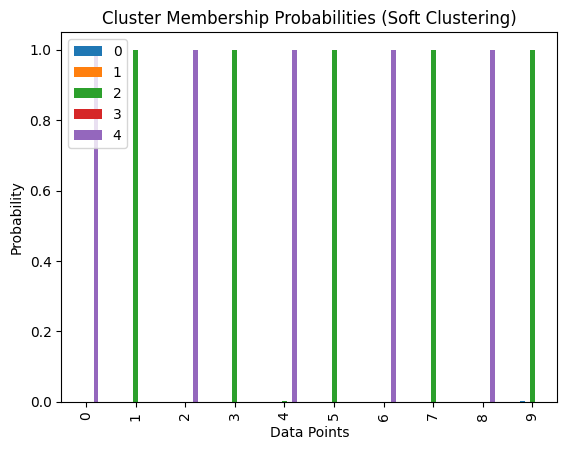

In [18]:
# Plot probability distribution for first 10 samples
plt.figure(figsize=(10,5))
pd.DataFrame(probs[:10]).plot(kind='bar')
plt.title('Cluster Membership Probabilities (Soft Clustering)')
plt.xlabel('Data Points')
plt.ylabel('Probability')
plt.show()

In [15]:
# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

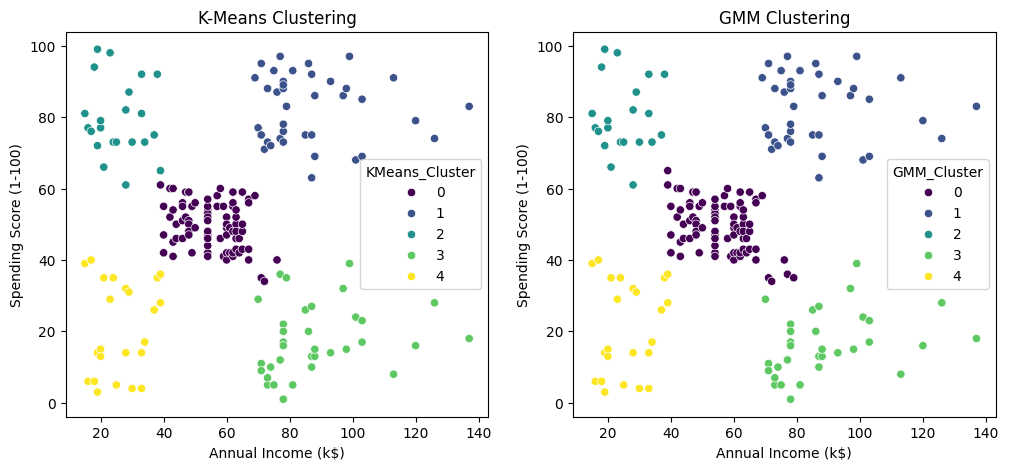

In [16]:
plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title('K-Means Clustering')

# GMM
plt.subplot(1,2,2)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)
plt.title('GMM Clustering')

plt.show()